<a href="https://colab.research.google.com/github/poorvikapalan/machine_learning/blob/main/program1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=sns.load_dataset('tips')
print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [5]:
num_col=df['total_bill']

In [6]:
z_scores = np.abs((num_col-num_col.mean())/num_col.std())
threshold = 3

outliers = z_scores[z_scores > threshold]
outlier_count = np.sum(outliers)

print("outliers:",outliers)
print("\nTotal Outliers (Z-score method):", outlier_count)


outliers: 59     3.199589
156    3.188356
170    3.484905
212    3.206329
Name: total_bill, dtype: float64

Total Outliers (Z-score method): 13.079177878830135


In [7]:
Q1 = num_col.quantile(0.25)
Q3 = num_col.quantile(0.75)
IQR = Q3 - Q1

iqr_outliers = ((num_col < (Q1 - 1.5 * IQR)) |
                (num_col > (Q3 + 1.5 * IQR)))


print("\nIQR outliers:")
print(iqr_outliers.sum())


IQR outliers:
9


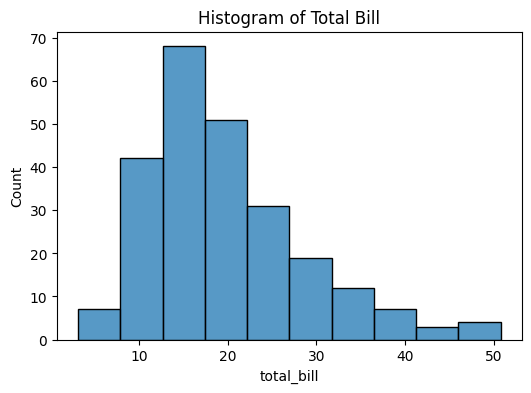

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(num_col, bins=10)
plt.title("Histogram of Total Bill")
plt.show()

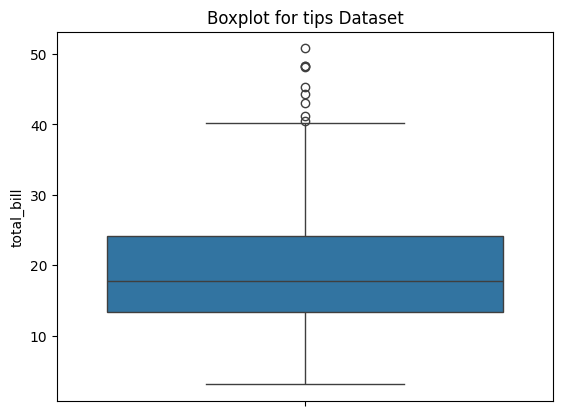

In [9]:
plt.figure()
sns.boxplot(num_col)
plt.title("Boxplot for tips Dataset")
plt.ylabel('total_bill')
plt.show()

In [10]:
correlation_matrix = df.corr(numeric_only=True)
print("\nCorrelation Matrix:\n",correlation_matrix)



Correlation Matrix:
             total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


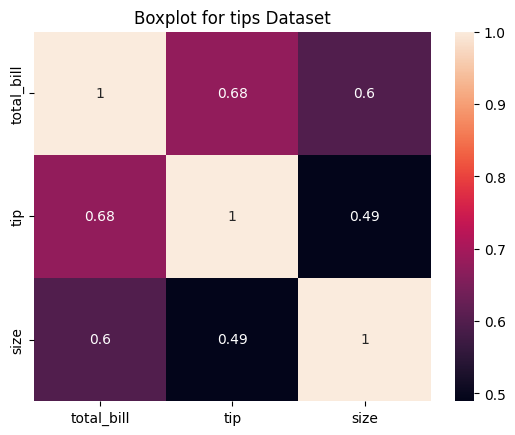

In [11]:
plt.figure()
sns.heatmap(correlation_matrix,annot=True)
plt.title("Boxplot for tips Dataset")
plt.show()

In [12]:
mean=num_col.mean()
median = num_col.median()
mode = num_col.mode()[0]
std_dev=num_col.std()
variance=num_col.var()
#statistical results
statistics = pd.DataFrame({
    'Mean': [mean],
    'Median': [median],
    'Mode': [mode],
    'standard deviation':[std_dev],
    'variance':[variance]
})
import csv
statistics.to_csv("statistics_result1.csv")